# Element and Bond distributions

This notebooks looks at the distribution of elements and bond types inside PDBbind and the OOD-Test train test split of PDBbind. 

This is useful for identifying which elements and bonds to include as node and edge features, as well as how to structure the intramolecular AEVs for the ligand. 

This notebook requires you to have run identify_elt_bond_types.py for both PDBbind and CASF-2016. You can read the doc-string for further information but we provide an example usage below:

python identify_elt_bond_types.py --processed_file data/PDBbind_minus_CASF_2016_processed.csv --output_dir data/graph_stats --output_tag PDBbind_train


In [1]:
# Get project root for file paths
from pathlib import Path

notebook_path = Path().resolve()
project_root = notebook_path.parent
data_dir = project_root / "data"
plots_dir = project_root / "output" / "notebook_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [50]:
import pandas as pd

# Load the bond and element statistics
graph_stats_dir = project_root / "data" / "graph_stats"
bond_stats_CASF_path = graph_stats_dir / "bond_statistics_CASF_2016.csv"
element_stats_CASF_path = graph_stats_dir / "element_statistics_CASF_2016.csv"
bond_stats_PDBbind_train_path = graph_stats_dir / "bond_statistics_PDBbind_train.csv"
element_stats_PDBbind_train_path = graph_stats_dir / "element_statistics_PDBbind_train.csv"
bond_stats_OOD_test_path = graph_stats_dir / "bond_statistics_OOD_test.csv"
element_stats_OOD_test_path = graph_stats_dir / "element_statistics_OOD_test.csv"
bond_stats_OOD_test_train_path = graph_stats_dir / "bond_statistics_OOD_train.csv"
element_stats_OOD_test_train_path = graph_stats_dir / "element_statistics_OOD_train.csv"

df_casf_elts = pd.read_csv(element_stats_CASF_path).rename(columns={'Unnamed: 0': 'Element'})
df_casf_bonds = pd.read_csv(bond_stats_CASF_path).rename(columns={'Unnamed: 0': 'Bond_Type'})
df_pdbbind_elts = pd.read_csv(element_stats_PDBbind_train_path).rename(columns={'Unnamed: 0': 'Element'})
df_pdbbind_bonds = pd.read_csv(bond_stats_PDBbind_train_path).rename(columns={'Unnamed: 0': 'Bond_Type'})
df_ood_test_elts = pd.read_csv(element_stats_OOD_test_path).rename(columns={'Unnamed: 0': 'Element'})
df_ood_test_bonds = pd.read_csv(bond_stats_OOD_test_path).rename(columns={'Unnamed: 0': 'Bond_Type'})
df_ood_train_elts = pd.read_csv(element_stats_OOD_test_train_path).rename(columns={'Unnamed: 0': 'Element'})
df_ood_train_bonds = pd.read_csv(bond_stats_OOD_test_train_path).rename(columns={'Unnamed: 0': 'Bond_Type'})


In [51]:
df_casf_elts.head()


,Element,Raw_Count,Complex_Occurance,Percent_of_Dataset
0,H,5720,285,100.000000
1,C,4963,285,100.000000
2,O,950,262,91.929825
3,N,856,257,90.175439
4,S,80,73,25.614035


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
def generate_horiz_bar(df, y_value, title, ylabel, save_path):
    # Sort df by percent of dataset
    df_sorted = df.sort_values('Percent_of_Dataset', ascending=False)
    fig = plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_sorted, x="Percent_of_Dataset", y=y_value, hue=y_value, legend=False)

    # Due to some categories having very small percentages we add the raw percentages as labels
    for container in ax.containers: 
        ax.bar_label(container, fmt='%.2f%%', padding=5)

    plt.xlim(0, df['Percent_of_Dataset'].max() * 1.15)
    
    plt.title(title)
    plt.xlabel("Percentage of Dataset (%)")
    plt.ylabel(ylabel)
    fig.savefig(save_path)
    plt.show()

def generate_horiz_bar_raw(df, y_value, title, ylabel, save_path):
    # Sort df by Complex Occurance of dataset
    df_sorted = df.sort_values('Complex_Occurance', ascending=False)
    fig = plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_sorted, x="Complex_Occurance", y=y_value, hue=y_value, legend=False)

    # Due to some categories having very small percentages we add the raw percentages as labels
    for container in ax.containers: 
        ax.bar_label(container, fmt='%d', padding=5)

    plt.xlim(0, df['Complex_Occurance'].max() * 1.15)
    
    plt.title(title)
    plt.xlabel("Number of complexes with at least one of the element")
    plt.ylabel(ylabel)
    fig.savefig(save_path)
    plt.show()

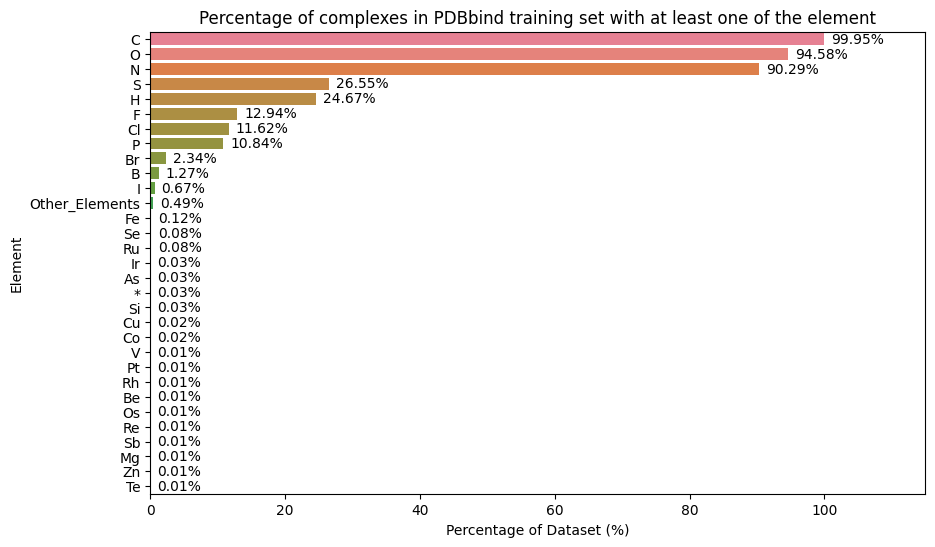

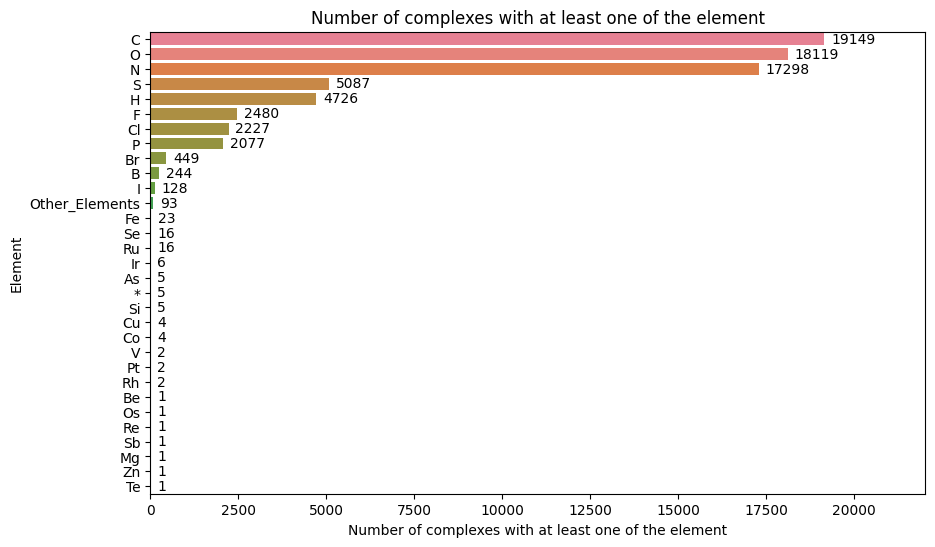

In [ ]:

generate_horiz_bar(df=df_pdbbind_elts, y_value="Element", title="Percentage of complexes in PDBbind training set with at least one of the element", ylabel="Element", save_path=(plots_dir / "PDBbind_element_dist.png").resolve() )
generate_horiz_bar_raw(df=df_pdbbind_elts, y_value="Element", title="Number of complexes in PDBbind training set with at least one of the element", ylabel="Element", save_path=(plots_dir / "PDBbind_element_dist_raw.png").resolve())